In [1]:
import pandas as pd
from pathlib import Path

# Opción 1: ruta absoluta directa (más simple)
PANEL_PATH = Path("/Users/alejandrahernandez/Documents/MPADSPP/DSPP/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

# Opción 2: relativa desde el notebook (si el notebook está en la raíz del repo)
# PANEL_PATH = Path("data/processed_data/analysis_panel.parquet")

panel = pd.read_parquet(PANEL_PATH, engine="fastparquet")
print(panel.shape)
print(panel.dtypes)
panel.head(3)

(16576, 35)
YEAR                              int16
GEOGRAPHY_CODE                 category
GEOGRAPHY_NAME                 category
IS8_SECTOR                     category
EMPLOYEES                       float32
BUSINESSES                      float32
unemployment_rate               float64
transport_to_employer           float64
drive_to_employer               float64
cycle_to_employer               float64
broadband                       float64
coverage_4g                     float64
gcse_age19                      float64
apprenticeship_starts           float64
apprenticeship_achievements     float64
nvq_level3                      float64
fe_participation                float64
housing_net_additions           float64
enterprise_birth_rate           float64
enterprise_death_rate           float64
enterprise_high_growth_rate     float64
REGION                           object
COUNTY_UA                        object
n_universities_feecap_lad         int64
lq_bus                      

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,IS8_SECTOR,EMPLOYEES,BUSINESSES,unemployment_rate,transport_to_employer,drive_to_employer,cycle_to_employer,...,emp_share,lq_emp,gd_emp,gd_bus,n_years_emp,n_years_bus,related_variety,within_sector_diversity,size_large_share,size_micro_share
0,2016,E06000001,Hartlepool,Advanced Manufacturing,1470.0,25.0,4.6,12.900208,7.790802,10.070582,...,0.048197,1.648198,0.001431,-0.112731,8,8,1.032564,1.332179,0.0,1.0
1,2016,E06000001,Hartlepool,Creative Industries,450.0,110.0,4.6,12.900208,7.790802,10.070582,...,0.014754,0.281144,0.044382,-0.014263,8,8,1.032564,2.200516,0.0,1.0
2,2016,E06000001,Hartlepool,Defence,0.0,0.0,4.6,12.900208,7.790802,10.070582,...,0.000000,0.000000,NaN,NaN,0,0,1.032564,0.000000,NaN,NaN


/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/855092115.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/855092115.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]


Tasa de crecimiento total nacional: 8.0%

Tasas por sector:
IS8_SECTOR
Advanced Manufacturing               -0.052
Creative Industries                   0.147
Defence                               0.019
Digital and Technologies              0.105
Financial Services                   -0.012
Life Sciences                         0.266
Professional and Business Services    0.100
Name: g_sector, dtype: float32

Shift-Share — South Yorkshire MCA  (2016→2022)
                        IS8_SECTOR    base     end  total_change  national_effect  industry_effect  competitive_effect
            Advanced Manufacturing  9050.0 11990.0        2940.0            726.0          -1198.0              3411.0
               Creative Industries 14020.0 15700.0        1680.0           1125.0            942.0              -387.0
                           Defence     0.0     0.0           0.0              0.0             -0.0                 NaN
          Digital and Technologies 24230.0 24790.0         560.0  

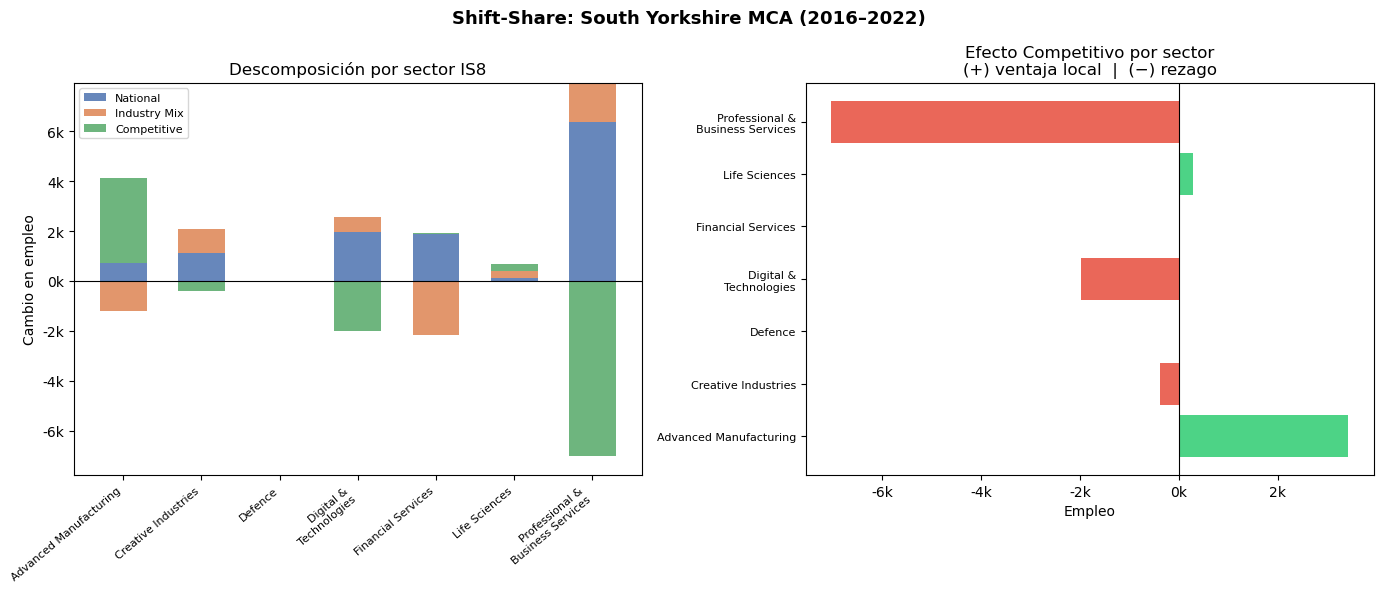


Listo. Archivos guardados: CSV y gráfico de barras.


In [2]:
"""
Shift-Share Analysis para IS8 — South Yorkshire MCA
Usa el dataframe `panel` ya construido (LAD x IS8_SECTOR x YEAR)

Columnas clave usadas: YEAR, GEOGRAPHY_CODE, GEOGRAPHY_NAME,
                       IS8_SECTOR, EMPLOYEES
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np

# ── CONFIG ───────────────────────────────────────────────────────────────────
YEAR_BASE   = 2016
YEAR_END    = 2022
REGION_NAME = "South Yorkshire MCA"
SECTOR_MAP  = "Advanced Manufacturing"

# LAD codes de South Yorkshire
REGION_LADS = ["E08000016", "E08000017", "E08000018", "E08000019"]
# Barnsley, Doncaster, Rotherham, Sheffield


# ── 1. REFERENTE NACIONAL (todos los LADs del panel) ─────────────────────────
# Usamos todos los LADs del panel como proxy del total nacional

# Tasa de crecimiento total nacional (suma todos los sectores IS8)
nat_total = (
    panel[panel["YEAR"].isin([YEAR_BASE, YEAR_END])]
    .groupby("YEAR")["EMPLOYEES"]
    .sum()
)
g_nat = (nat_total[YEAR_END] - nat_total[YEAR_BASE]) / nat_total[YEAR_BASE]

# Tasa de crecimiento nacional por sector IS8
nat_sec = (
    panel[panel["YEAR"].isin([YEAR_BASE, YEAR_END])]
    .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
    .sum()
    .unstack("YEAR")
)
nat_sec["g_sector"] = (nat_sec[YEAR_END] - nat_sec[YEAR_BASE]) / nat_sec[YEAR_BASE]

print(f"Tasa de crecimiento total nacional: {g_nat:.1%}")
print("\nTasas por sector:")
print(nat_sec["g_sector"].round(3))

# ── 2. EMPLEO REGIONAL (South Yorkshire) ─────────────────────────────────────
reg = (
    panel[
        panel["GEOGRAPHY_CODE"].isin(REGION_LADS) &
        panel["YEAR"].isin([YEAR_BASE, YEAR_END])
    ]
    .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
    .sum()
    .unstack("YEAR")
    .rename(columns={YEAR_BASE: "base", YEAR_END: "end"})
    .reset_index()
)

# ── 3. SHIFT-SHARE ────────────────────────────────────────────────────────────
ss = reg.merge(nat_sec[["g_sector"]].reset_index(), on="IS8_SECTOR", how="left")

ss["g_region"] = (ss["end"] - ss["base"]) / ss["base"].replace(0, np.nan)

ss["national_effect"]    = ss["base"] * g_nat
ss["industry_effect"]    = ss["base"] * (ss["g_sector"] - g_nat)
ss["competitive_effect"] = ss["base"] * (ss["g_region"] - ss["g_sector"])
ss["total_change"]       = ss["end"] - ss["base"]

# Verificación: los tres efectos deben sumar total_change
ss["check"] = (ss[["national_effect","industry_effect","competitive_effect"]].sum(axis=1)
               - ss["total_change"]).abs().round(1)

print(f"\n{'='*60}")
print(f"Shift-Share — {REGION_NAME}  ({YEAR_BASE}→{YEAR_END})")
print(f"{'='*60}")
cols_show = ["IS8_SECTOR","base","end","total_change",
             "national_effect","industry_effect","competitive_effect"]
print(ss[cols_show].round(0).to_string(index=False))

ss[cols_show].round(0).to_csv(
    f"shift_share_{REGION_NAME.replace(' ','_')}.csv", index=False)

# ── 4. GRÁFICO: Descomposición + Efecto Competitivo ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Shift-Share: {REGION_NAME} ({YEAR_BASE}–{YEAR_END})",
             fontsize=13, fontweight="bold")

sectors_lbl = ss["IS8_SECTOR"].str.replace(" and ", " &\n", regex=False).values
x = np.arange(len(ss))

# Panel izquierdo: barras apiladas de los tres efectos
ax1 = axes[0]
effect_cols = {
    "National":     (ss["national_effect"].values,    "#4C72B0"),
    "Industry Mix": (ss["industry_effect"].values,    "#DD8452"),
    "Competitive":  (ss["competitive_effect"].values, "#55A868"),
}
bot_pos = np.zeros(len(ss))
bot_neg = np.zeros(len(ss))
for label, (vals, color) in effect_cols.items():
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)
    ax1.bar(x, pos, bottom=bot_pos, label=label, color=color, width=0.6, alpha=0.85)
    ax1.bar(x, neg, bottom=bot_neg, color=color, width=0.6, alpha=0.85)
    bot_pos += pos
    bot_neg += neg

ax1.axhline(0, color="black", lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(sectors_lbl, rotation=40, ha="right", fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax1.set_ylabel("Cambio en empleo")
ax1.set_title("Descomposición por sector IS8")
ax1.legend(fontsize=8)

# Panel derecho: efecto competitivo horizontal
ax2 = axes[1]
comp = ss["competitive_effect"].values
cols = ["#2ecc71" if v >= 0 else "#e74c3c" for v in comp]
ax2.barh(x, comp, color=cols, alpha=0.85)
ax2.axvline(0, color="black", lw=0.8)
ax2.set_yticks(x)
ax2.set_yticklabels(sectors_lbl, fontsize=8)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax2.set_xlabel("Empleo")
ax2.set_title("Efecto Competitivo por sector\n(+) ventaja local  |  (−) rezago")

plt.tight_layout()
plt.savefig(f"shift_share_{REGION_NAME.replace(' ','_')}.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nListo. Archivos guardados: CSV y gráfico de barras.")


In [10]:
from pathlib import Path

matches = list(Path("/Users/alejandrahernandez/Documents/MPADSPP/DSPP/GitHub/Economic_Observatory").rglob("*LAD*.geojson"))
for m in matches:
    print(m)


/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/975679679.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/975679679.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]


Tasa de crecimiento total nacional: 8.0%

Tasas por sector:
IS8_SECTOR
Advanced Manufacturing               -0.052
Creative Industries                   0.147
Defence                               0.019
Digital and Technologies              0.105
Financial Services                   -0.012
Life Sciences                         0.266
Professional and Business Services    0.100
Name: g_sector, dtype: float32

Shift-Share — South Yorkshire MCA  (2016→2022)
                        IS8_SECTOR    base     end  total_change  national_effect  industry_effect  competitive_effect
            Advanced Manufacturing  9050.0 11990.0        2940.0            726.0          -1198.0              3411.0
               Creative Industries 14020.0 15700.0        1680.0           1125.0            942.0              -387.0
                           Defence     0.0     0.0           0.0              0.0             -0.0                 NaN
          Digital and Technologies 24230.0 24790.0         560.0  

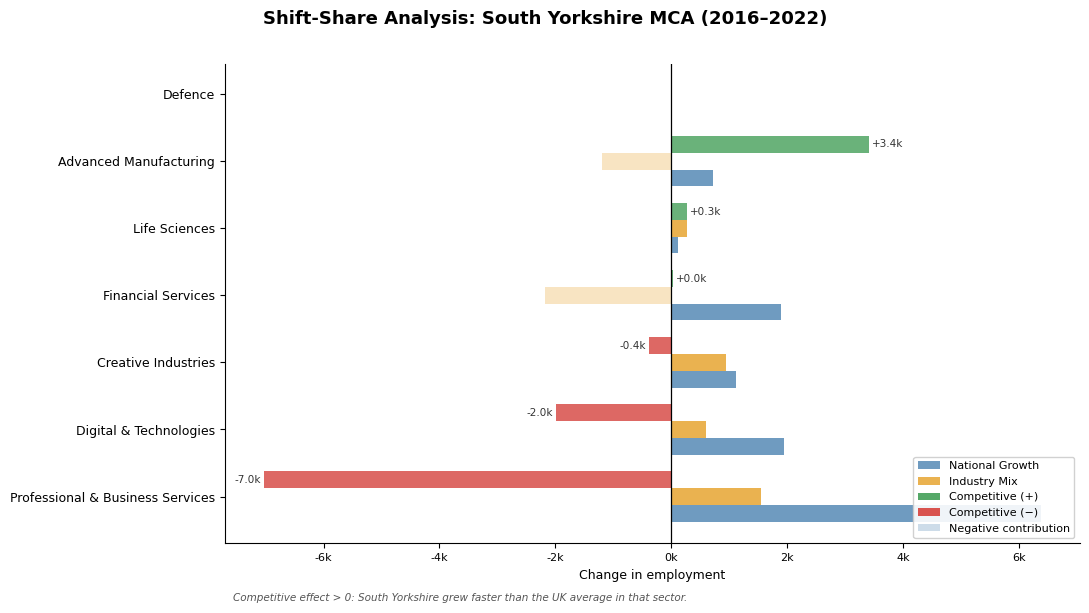


Listo. Archivos guardados: CSV y gráfico de barras.


In [3]:
"""
Shift-Share Analysis para IS8 — South Yorkshire MCA
Usa el dataframe `panel` ya construido (LAD x IS8_SECTOR x YEAR)

Columnas clave usadas: YEAR, GEOGRAPHY_CODE, GEOGRAPHY_NAME,
                       IS8_SECTOR, EMPLOYEES
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np

# ── CONFIG ───────────────────────────────────────────────────────────────────
YEAR_BASE   = 2016
YEAR_END    = 2022
REGION_NAME = "South Yorkshire MCA"
SECTOR_MAP  = "Advanced Manufacturing"

# LAD codes de South Yorkshire
REGION_LADS = ["E08000016", "E08000017", "E08000018", "E08000019"]
# Barnsley, Doncaster, Rotherham, Sheffield


# ── 1. REFERENTE NACIONAL (todos los LADs del panel) ─────────────────────────
# Usamos todos los LADs del panel como proxy del total nacional

# Tasa de crecimiento total nacional (suma todos los sectores IS8)
nat_total = (
    panel[panel["YEAR"].isin([YEAR_BASE, YEAR_END])]
    .groupby("YEAR")["EMPLOYEES"]
    .sum()
)
g_nat = (nat_total[YEAR_END] - nat_total[YEAR_BASE]) / nat_total[YEAR_BASE]

# Tasa de crecimiento nacional por sector IS8
nat_sec = (
    panel[panel["YEAR"].isin([YEAR_BASE, YEAR_END])]
    .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
    .sum()
    .unstack("YEAR")
)
nat_sec["g_sector"] = (nat_sec[YEAR_END] - nat_sec[YEAR_BASE]) / nat_sec[YEAR_BASE]

print(f"Tasa de crecimiento total nacional: {g_nat:.1%}")
print("\nTasas por sector:")
print(nat_sec["g_sector"].round(3))

# ── 2. EMPLEO REGIONAL (South Yorkshire) ─────────────────────────────────────
reg = (
    panel[
        panel["GEOGRAPHY_CODE"].isin(REGION_LADS) &
        panel["YEAR"].isin([YEAR_BASE, YEAR_END])
    ]
    .groupby(["YEAR", "IS8_SECTOR"])["EMPLOYEES"]
    .sum()
    .unstack("YEAR")
    .rename(columns={YEAR_BASE: "base", YEAR_END: "end"})
    .reset_index()
)

# ── 3. SHIFT-SHARE ────────────────────────────────────────────────────────────
ss = reg.merge(nat_sec[["g_sector"]].reset_index(), on="IS8_SECTOR", how="left")

ss["g_region"] = (ss["end"] - ss["base"]) / ss["base"].replace(0, np.nan)

ss["national_effect"]    = ss["base"] * g_nat
ss["industry_effect"]    = ss["base"] * (ss["g_sector"] - g_nat)
ss["competitive_effect"] = ss["base"] * (ss["g_region"] - ss["g_sector"])
ss["total_change"]       = ss["end"] - ss["base"]

# Verificación: los tres efectos deben sumar total_change
ss["check"] = (ss[["national_effect","industry_effect","competitive_effect"]].sum(axis=1)
               - ss["total_change"]).abs().round(1)

print(f"\n{'='*60}")
print(f"Shift-Share — {REGION_NAME}  ({YEAR_BASE}→{YEAR_END})")
print(f"{'='*60}")
cols_show = ["IS8_SECTOR","base","end","total_change",
             "national_effect","industry_effect","competitive_effect"]
print(ss[cols_show].round(0).to_string(index=False))

ss[cols_show].round(0).to_csv(
    f"shift_share_{REGION_NAME.replace(' ','_')}.csv", index=False)

# ── 4. GRÁFICO COMBINADO ─────────────────────────────────────────────────────
# Ordena sectores por efecto competitivo para lectura más clara
ss_sorted = ss.sort_values("competitive_effect", ascending=True).reset_index(drop=True)
sectors_lbl = ss_sorted["IS8_SECTOR"].str.replace(" and ", " & ", regex=False).values
x = np.arange(len(ss_sorted))

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle(f"Shift-Share Analysis: {REGION_NAME} ({YEAR_BASE}–{YEAR_END})",
             fontsize=13, fontweight="bold", y=1.01)

bar_w = 0.25
# Tres grupos de barras lado a lado
bars = [
    ("National Growth",  ss_sorted["national_effect"].values,    "#5B8DB8"),
    ("Industry Mix",     ss_sorted["industry_effect"].values,    "#E8A838"),
    ("Competitive",      ss_sorted["competitive_effect"].values, "#55A868"),
]
offsets = [-bar_w, 0, bar_w]

for (label, vals, color), offset in zip(bars, offsets):
    for i, v in enumerate(vals):
        if label == "Competitive":
            bar_color = "#55A868" if v >= 0 else "#d9534f"
            alpha = 0.88
        else:
            bar_color = color
            alpha = 0.88 if v >= 0 else 0.3
        ax.barh(x[i] + offset, v, height=bar_w, color=bar_color, alpha=alpha)

# Línea de referencia en cero
ax.axvline(0, color="black", lw=0.9, zorder=3)

# Etiquetas de valor en el efecto competitivo (el más relevante)
for i, v in enumerate(ss_sorted["competitive_effect"].values):
    ha = "left" if v >= 0 else "right"
    pad = 50 if v >= 0 else -50
    ax.text(v + pad, x[i] + bar_w, f"{v/1000:+.1f}k",
            va="center", ha=ha, fontsize=7.5, color="#333333")

ax.set_yticks(x)
ax.set_yticklabels(sectors_lbl, fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.set_xlabel("Change in employment", fontsize=9)
ax.tick_params(axis="x", labelsize=8)

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5B8DB8", alpha=0.88, label="National Growth"),
    Patch(facecolor="#E8A838", alpha=0.88, label="Industry Mix"),
    Patch(facecolor="#55A868", label="Competitive (+)"),
    Patch(facecolor="#d9534f", label="Competitive (−)"),
    Patch(facecolor="#5B8DB8", alpha=0.3,  label="Negative contribution"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right",
          framealpha=0.9, edgecolor="#cccccc")

# Anotación explicativa
ax.text(0.01, -0.12,
        "Competitive effect > 0: South Yorkshire grew faster than the UK average in that sector.",
        transform=ax.transAxes, fontsize=7.5, color="#555555", style="italic")

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"shift_share_{REGION_NAME.replace(' ','_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nListo. Archivos guardados: CSV y gráfico de barras.")

/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/2024416384.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])[metric]
/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/2024416384.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["YEAR", "IS8_SECTOR"])[metric]
/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/2024416384.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt th


[EMPLOYEES] Tasa de crecimiento nacional total: 8.0%

[BUSINESSES] Tasa de crecimiento nacional total: -2.6%

── Empleo ──
                        IS8_SECTOR    base     end  national_effect  industry_effect  competitive_effect
            Advanced Manufacturing  9050.0 11990.0            726.0          -1198.0              3411.0
               Creative Industries 14020.0 15700.0           1125.0            942.0              -387.0
                           Defence     0.0     0.0              0.0             -0.0                 NaN
          Digital and Technologies 24230.0 24790.0           1945.0            606.0             -1991.0
                Financial Services 23645.0 23390.0           1898.0          -2180.0                27.0
                     Life Sciences  1440.0  2105.0            116.0            268.0               282.0
Professional and Business Services 79560.0 80470.0           6386.0           1556.0             -7032.0

── Negocios ──
                    

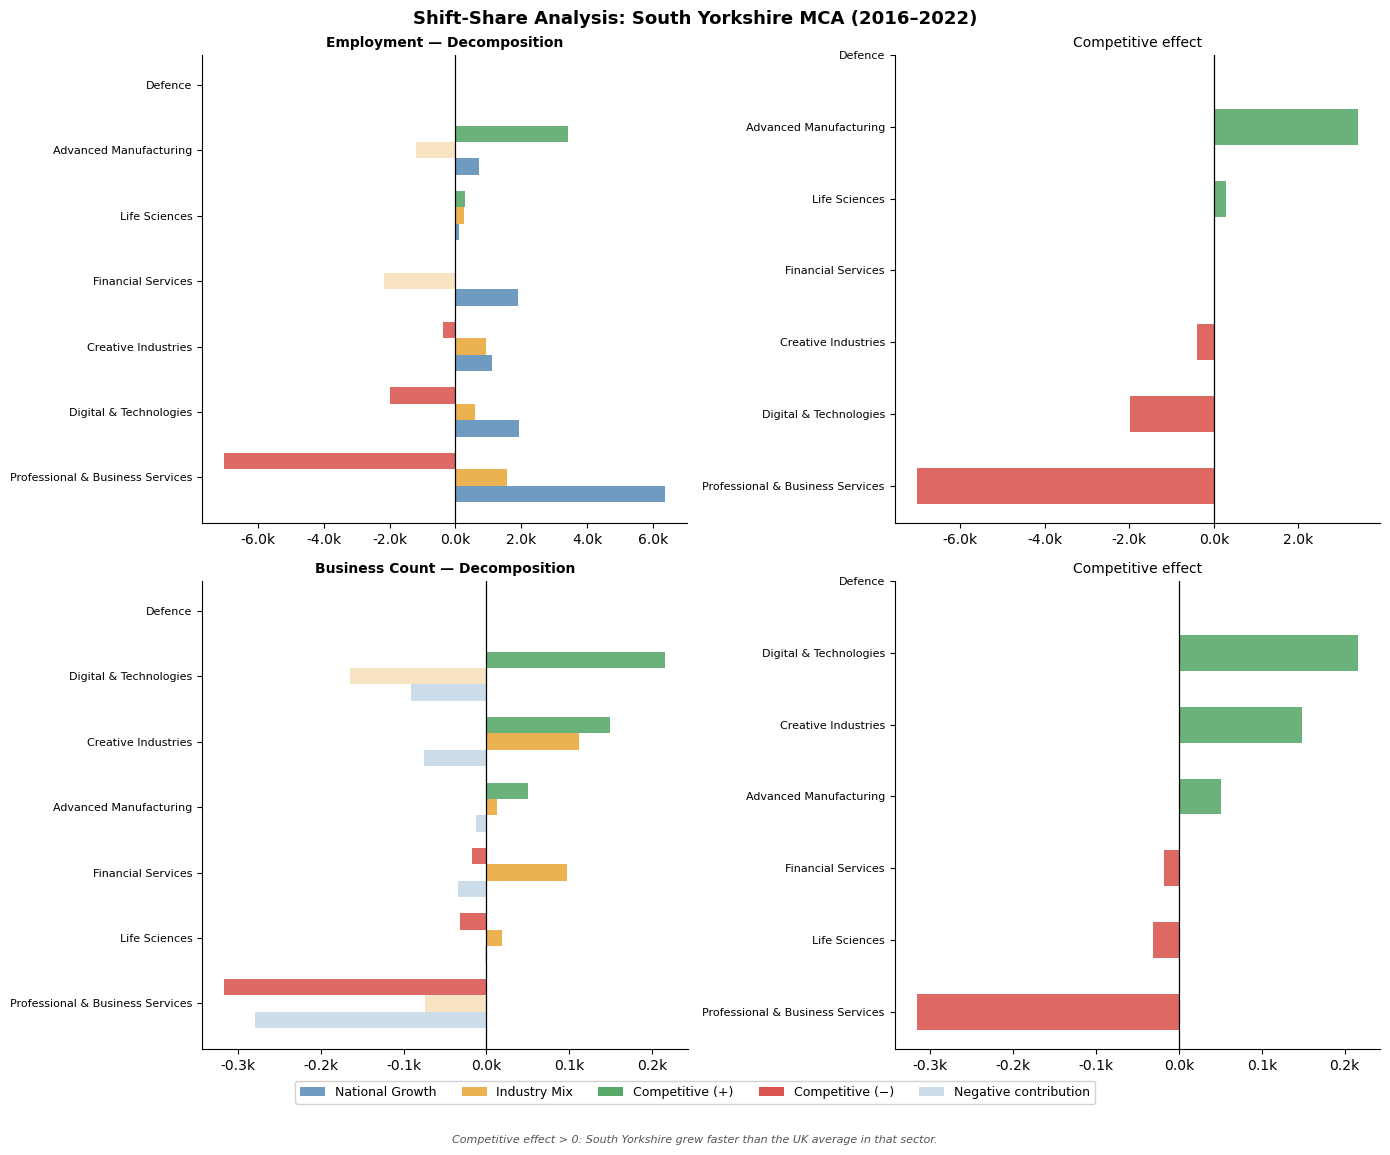

/var/folders/b9/rs93d4m56vvcjd2pb8zhzwf40000gn/T/ipykernel_67437/2024416384.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["GEOGRAPHY_CODE", "GEOGRAPHY_NAME", "YEAR"])["EMPLOYEES"]


In [ ]:
"""
Shift-Share Analysis para IS8 — South Yorkshire MCA
Usa el dataframe `panel` ya construido (LAD x IS8_SECTOR x YEAR)

Columnas clave usadas: YEAR, GEOGRAPHY_CODE, GEOGRAPHY_NAME,
                       IS8_SECTOR, EMPLOYEES
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np

# ── CONFIG ───────────────────────────────────────────────────────────────────
YEAR_BASE   = 2016
YEAR_END    = 2022
REGION_NAME = "South Yorkshire MCA"
SECTOR_MAP  = "Advanced Manufacturing"

# LAD codes de South Yorkshire
REGION_LADS = ["E08000016", "E08000017", "E08000018", "E08000019"]
# Barnsley, Doncaster, Rotherham, Sheffield


# ── FUNCIÓN AUXILIAR: Shift-Share genérico ───────────────────────────────────
def compute_shift_share(df, metric, year_base, year_end, region_lads):
    """
    Calcula shift-share para cualquier métrica (EMPLOYEES o BUSINESSES).
    Devuelve (ss_regional, nat_sec) donde:
      ss_regional: DataFrame con los tres efectos por sector IS8
      nat_sec:     DataFrame con tasas de crecimiento nacionales por sector
    """
    # Referente nacional
    nat_total = (
        df[df["YEAR"].isin([year_base, year_end])]
        .groupby("YEAR")[metric].sum()
    )
    g_nat = (nat_total[year_end] - nat_total[year_base]) / nat_total[year_base]

    nat_sec = (
        df[df["YEAR"].isin([year_base, year_end])]
        .groupby(["YEAR", "IS8_SECTOR"])[metric]
        .sum()
        .unstack("YEAR")
    )
    nat_sec["g_sector"] = (nat_sec[year_end] - nat_sec[year_base]) / nat_sec[year_base]

    # Empleo/negocios regional
    reg = (
        df[df["GEOGRAPHY_CODE"].isin(region_lads) &
           df["YEAR"].isin([year_base, year_end])]
        .groupby(["YEAR", "IS8_SECTOR"])[metric]
        .sum()
        .unstack("YEAR")
        .rename(columns={year_base: "base", year_end: "end"})
        .reset_index()
    )

    ss = reg.merge(nat_sec[["g_sector"]].reset_index(), on="IS8_SECTOR", how="left")
    ss["g_region"]           = (ss["end"] - ss["base"]) / ss["base"].replace(0, np.nan)
    ss["national_effect"]    = ss["base"] * g_nat
    ss["industry_effect"]    = ss["base"] * (ss["g_sector"] - g_nat)
    ss["competitive_effect"] = ss["base"] * (ss["g_region"] - ss["g_sector"])
    ss["total_change"]       = ss["end"] - ss["base"]

    print(f"\n[{metric}] Tasa de crecimiento nacional total: {g_nat:.1%}")
    return ss, nat_sec, g_nat

# ── 1. CALCULAR PARA EMPLEO Y NEGOCIOS ───────────────────────────────────────
ss_emp,  nat_sec_emp,  g_nat_emp  = compute_shift_share(panel, "EMPLOYEES",  YEAR_BASE, YEAR_END, REGION_LADS)
ss_bus,  nat_sec_bus,  g_nat_bus  = compute_shift_share(panel, "BUSINESSES", YEAR_BASE, YEAR_END, REGION_LADS)

# Alias para compatibilidad con el resto del código
ss      = ss_emp
nat_sec = nat_sec_emp
g_nat   = g_nat_emp

print("\n── Empleo ──")
print(ss_emp[["IS8_SECTOR","base","end","national_effect","industry_effect","competitive_effect"]].round(0).to_string(index=False))
print("\n── Negocios ──")
print(ss_bus[["IS8_SECTOR","base","end","national_effect","industry_effect","competitive_effect"]].round(0).to_string(index=False))

# ── 2-3. SHIFT-SHARE (calculado en función auxiliar arriba) ──────────────────
cols_show = ["IS8_SECTOR","base","end","total_change",
             "national_effect","industry_effect","competitive_effect"]
ss_emp[cols_show].round(0).to_csv(f"shift_share_emp_{REGION_NAME.replace(' ','_')}.csv", index=False)
ss_bus[cols_show].round(0).to_csv(f"shift_share_bus_{REGION_NAME.replace(' ','_')}.csv", index=False)

# ── 4. GRÁFICO COMPARATIVO: Empleo vs Negocios ───────────────────────────────
def plot_combined(ss, title, ax_left, ax_right):
    ss_sorted = ss.sort_values("competitive_effect", ascending=True).reset_index(drop=True)
    sectors_lbl = ss_sorted["IS8_SECTOR"].str.replace(" and ", " & ", regex=False).values
    x = np.arange(len(ss_sorted))
    bar_w = 0.25
    bars = [
        ("National Growth", ss_sorted["national_effect"].values,    "#5B8DB8"),
        ("Industry Mix",    ss_sorted["industry_effect"].values,    "#E8A838"),
        ("Competitive",     ss_sorted["competitive_effect"].values, "#55A868"),
    ]
    offsets = [-bar_w, 0, bar_w]

    for (label, vals, color), offset in zip(bars, offsets):
        for i, v in enumerate(vals):
            if label == "Competitive":
                bar_color = "#55A868" if v >= 0 else "#d9534f"
                alpha = 0.88
            else:
                bar_color = color
                alpha = 0.88 if v >= 0 else 0.3
            ax_left.barh(x[i] + offset, v, height=bar_w, color=bar_color, alpha=alpha)

    ax_left.axvline(0, color="black", lw=0.9)
    ax_left.set_yticks(x)
    ax_left.set_yticklabels(sectors_lbl, fontsize=8)
    ax_left.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.1f}k"))
    ax_left.set_title(title, fontsize=10, fontweight="bold")
    ax_left.spines[["top","right"]].set_visible(False)

    # Panel derecho: solo efecto competitivo
    comp = ss_sorted["competitive_effect"].values
    cols = ["#55A868" if v >= 0 else "#d9534f" for v in comp]
    ax_right.barh(x, comp, color=cols, alpha=0.88, height=0.5)
    ax_right.axvline(0, color="black", lw=0.9)
    for i, v in enumerate(comp):
        ha = "left" if v >= 0 else "right"
        pad = abs(comp).max() * 0.02
        pad = pad if v >= 0 else -pad
        ax_right.text(v + pad, x[i], f"{v/1000:+.1f}k",
                      va="center", ha=ha, fontsize=8, fontweight="bold", color="#333333")
    ax_right.set_yticks(x)
    ax_right.set_yticklabels(sectors_lbl, fontsize=8)
    ax_right.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.1f}k"))
    ax_right.set_title("Competitive effect", fontsize=10)
    ax_right.spines[["top","right"]].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f"Shift-Share Analysis: {REGION_NAME} ({YEAR_BASE}–{YEAR_END})",
             fontsize=13, fontweight="bold")

plot_combined(ss_emp, "Employment — Decomposition", axes[0,0], axes[0,1])
plot_combined(ss_bus, "Business Count — Decomposition", axes[1,0], axes[1,1])

# Leyenda compartida
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5B8DB8", alpha=0.88, label="National Growth"),
    Patch(facecolor="#E8A838", alpha=0.88, label="Industry Mix"),
    Patch(facecolor="#55A868", label="Competitive (+)"),
    Patch(facecolor="#d9534f", label="Competitive (−)"),
    Patch(facecolor="#5B8DB8", alpha=0.3,  label="Negative contribution"),
]
fig.legend(handles=legend_elements, fontsize=9, loc="lower center",
           ncol=5, framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.text(0.5, -0.05,
         "Competitive effect > 0: South Yorkshire grew faster than the UK average in that sector.",
         ha="center", fontsize=8, color="#555555", style="italic")

plt.tight_layout()
plt.savefig(f"shift_share_emp_bus_{REGION_NAME.replace(' ','_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 5. GRÁFICO: Efecto competitivo por LAD dentro de South Yorkshire ──────────
reg_lad = (
    panel[
        (panel["GEOGRAPHY_CODE"].isin(REGION_LADS)) &
        (panel["IS8_SECTOR"].astype(str) == SECTOR_MAP) &
        (panel["YEAR"].isin([YEAR_BASE, YEAR_END]))
    ]
    .groupby(["GEOGRAPHY_CODE", "GEOGRAPHY_NAME", "YEAR"])["EMPLOYEES"]
    .sum()
    .unstack("YEAR")
    .rename(columns={YEAR_BASE: "base", YEAR_END: "end"})
    .reset_index()
)

g_sector_map = nat_sec.loc[SECTOR_MAP, "g_sector"]
reg_lad["g_region"]          = (reg_lad["end"] - reg_lad["base"]) / reg_lad["base"].replace(0, np.nan)
reg_lad["national_effect"]   = reg_lad["base"] * g_nat
reg_lad["industry_effect"]   = reg_lad["base"] * (g_sector_map - g_nat)
reg_lad["competitive_effect"]= reg_lad["base"] * (reg_lad["g_region"] - g_sector_map)
reg_lad["total_change"]      = reg_lad["end"] - reg_lad["base"]

# Ordena por efecto competitivo
reg_lad = reg_lad.sort_values("competitive_effect", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"{SECTOR_MAP} — LAD breakdown: {REGION_NAME} ({YEAR_BASE}–{YEAR_END})",
             fontsize=12, fontweight="bold")

lad_names = reg_lad["GEOGRAPHY_NAME"].values
x = np.arange(len(reg_lad))
bar_w = 0.25
offsets = [-bar_w, 0, bar_w]
bars_lad = [
    ("National Growth", reg_lad["national_effect"].values,    "#5B8DB8"),
    ("Industry Mix",    reg_lad["industry_effect"].values,    "#E8A838"),
    ("Competitive",     reg_lad["competitive_effect"].values, "#55A868"),
]

# Panel izquierdo: los tres efectos agrupados
ax1 = axes[0]
for (label, vals, color), offset in zip(bars_lad, offsets):
    for i, v in enumerate(vals):
        if label == "Competitive":
            bar_color = "#55A868" if v >= 0 else "#d9534f"
            alpha = 0.88
        else:
            bar_color = color
            alpha = 0.88 if v >= 0 else 0.3
        ax1.barh(x[i] + offset, v, height=bar_w, color=bar_color, alpha=alpha)

ax1.axvline(0, color="black", lw=0.9)
ax1.set_yticks(x)
ax1.set_yticklabels(lad_names, fontsize=9)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax1.set_xlabel("Change in employment", fontsize=9)
ax1.set_title("Shift-Share decomposition", fontsize=10)
ax1.spines[["top","right"]].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5B8DB8", alpha=0.88, label="National Growth"),
    Patch(facecolor="#E8A838", alpha=0.88, label="Industry Mix"),
    Patch(facecolor="#55A868", label="Competitive (+)"),
    Patch(facecolor="#d9534f", label="Competitive (−)"),
]
ax1.legend(handles=legend_elements, fontsize=7.5, loc="lower right",
           framealpha=0.9, edgecolor="#cccccc")

# Panel derecho: solo efecto competitivo con etiquetas de valor
ax2 = axes[1]
comp_vals = reg_lad["competitive_effect"].values
colors_comp = ["#55A868" if v >= 0 else "#d9534f" for v in comp_vals]
ax2.barh(x, comp_vals, color=colors_comp, alpha=0.88, height=0.5)
ax2.axvline(0, color="black", lw=0.9)

for i, v in enumerate(comp_vals):
    ha = "left" if v >= 0 else "right"
    pad = 20 if v >= 0 else -20
    ax2.text(v + pad, x[i], f"{v/1000:+.1f}k",
             va="center", ha=ha, fontsize=9, fontweight="bold", color="#333333")

ax2.set_yticks(x)
ax2.set_yticklabels(lad_names, fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax2.set_xlabel("Competitive effect (employment)", fontsize=9)
ax2.set_title("Competitive effect only", fontsize=10)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"shift_share_LAD_{SECTOR_MAP.replace(' ','_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nListo. Archivos guardados: CSV, gráfico regional y gráfico por LAD.")
